1. Dataset Loading

Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

Load Dataset

In [29]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


2. Dataset Overview

Shape

In [3]:
df.shape

(7043, 21)

Columns

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Statistical Summary

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


3. Data Cleaning

Missing Values

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(0)

Data Type Fixes

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Remove Unnecessary Column

In [11]:
df.drop('customerID', axis=1, inplace=True)

Remove Extra Spaces

In [12]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

4. Exploratory Data Analysis

Univariate Analysis - Numerical and Categorical Summaries

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [16]:
for col in df.select_dtypes(include='object'):
    print(df[col].value_counts(),"\n")

gender
Male      3555
Female    3488
Name: count, dtype: int64 

Partner
No     3641
Yes    3402
Name: count, dtype: int64 

Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64 

StreamingTV
No       

Bivariate Analysis

i.Contract vs Churn

In [17]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


ii.Internet Service vs Churn

In [18]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


iii.Payment Method vs Churn

In [19]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


5. Visualizations

Chart 1: Churn Count Plot

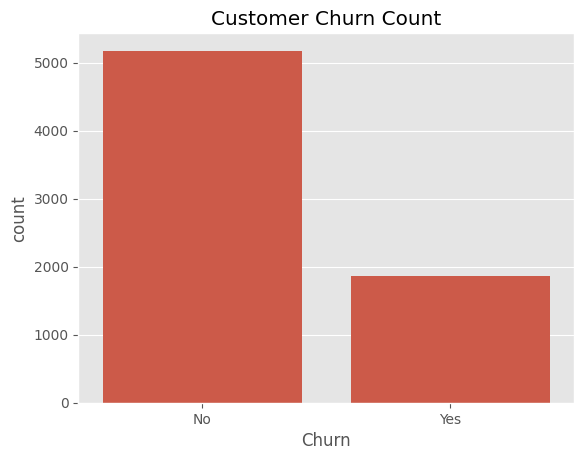

In [20]:
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Count')
plt.show()

Chart 2: Churn Percentage Pie Chart

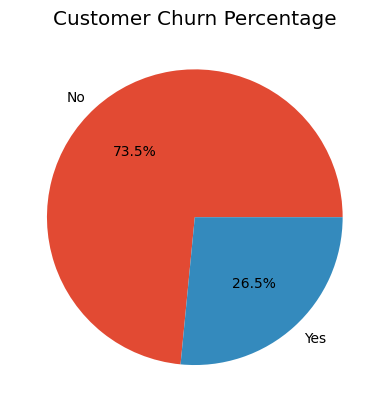

In [21]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Customer Churn Percentage')
plt.ylabel('')
plt.show()

Chart 3: Histogram

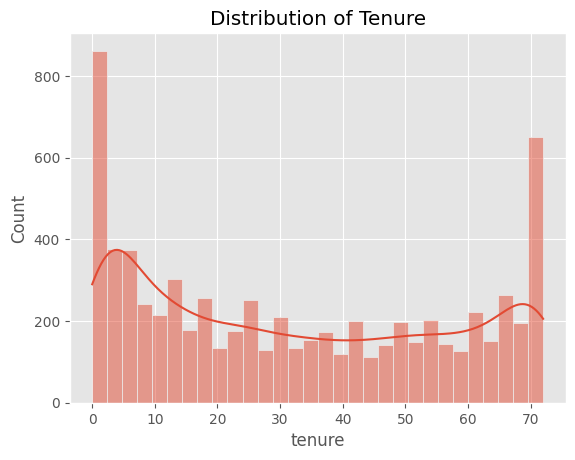

In [22]:
sns.histplot(df['tenure'],
             bins=30,
             kde=True)

plt.title('Distribution of Tenure')
plt.show()

Chart 4: Boxplot

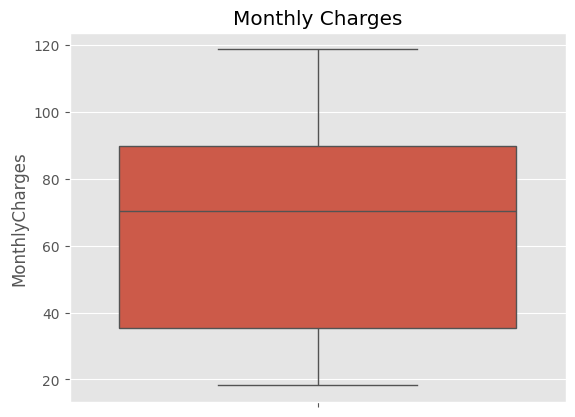

In [23]:
sns.boxplot(y=df['MonthlyCharges'])

plt.title('Monthly Charges')
plt.show()

Chart 5: Bar Chart

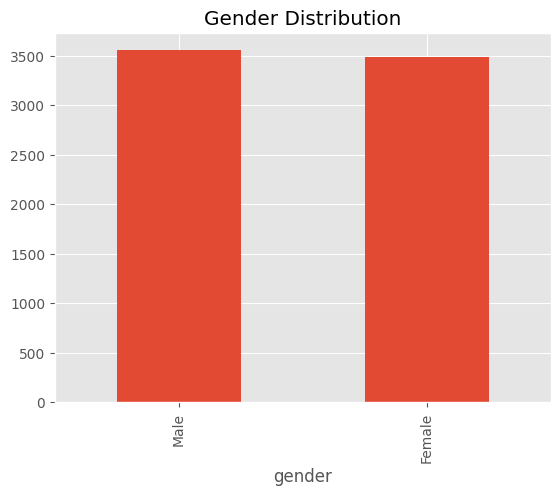

In [24]:
df['gender'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.show()

Chart 6: Countplot with Churn

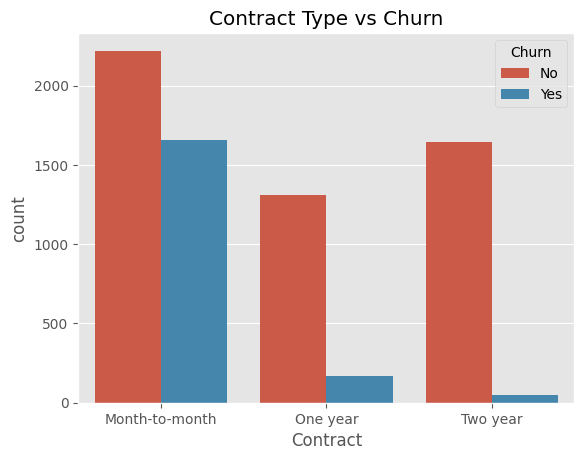

In [25]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract Type vs Churn')
plt.show()

Chart 7: Correlation Heatmap

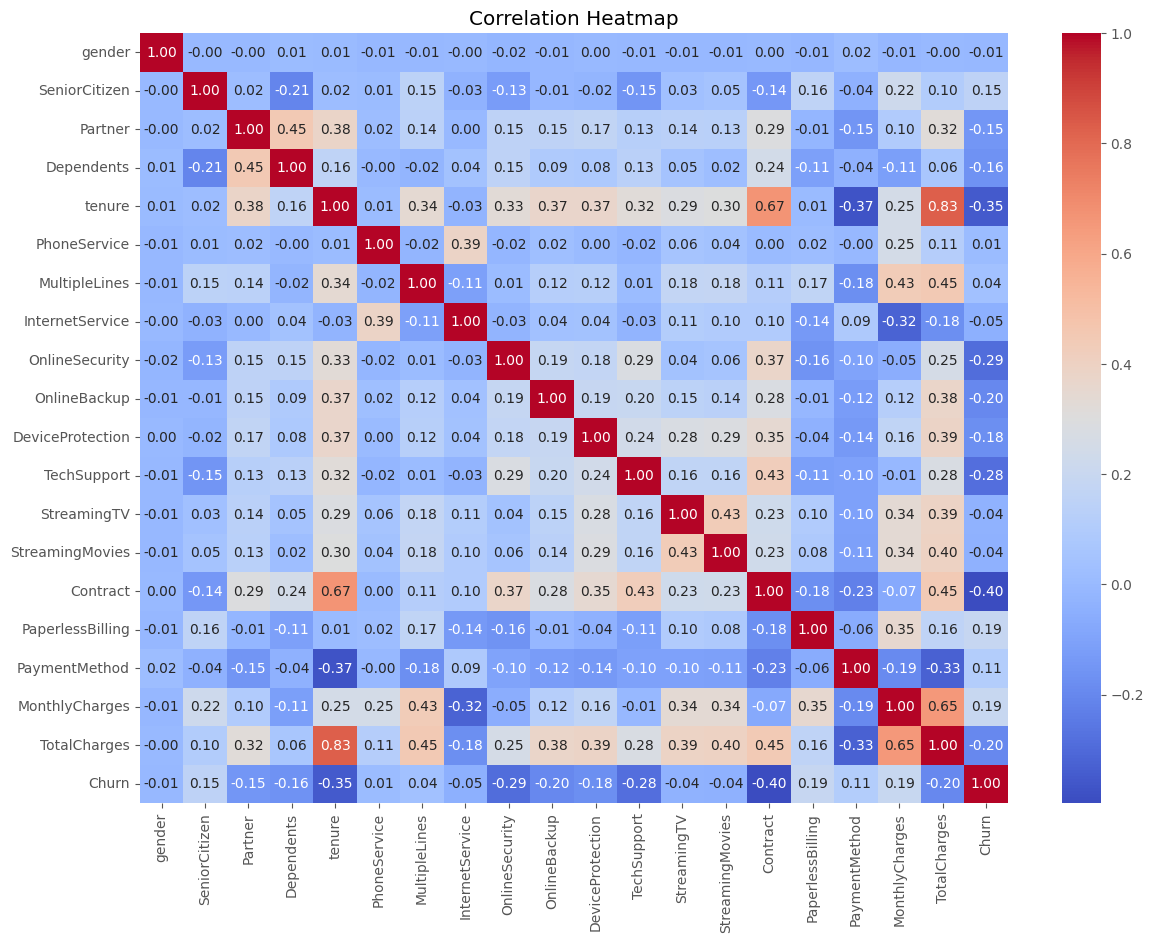

In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = encoder.fit_transform(df_encoded[col])

plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

Chart 8: Scatter Plot

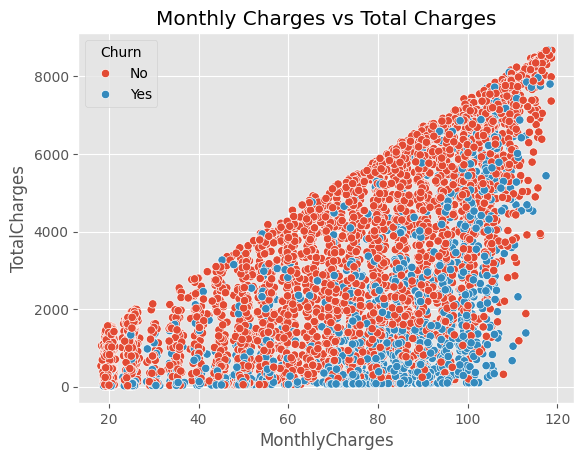

In [27]:
sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Churn',
    data=df
)

plt.title('Monthly Charges vs Total Charges')
plt.show()

# 6. Final Insights

##  Key Churn Patterns


*   Approximately 26–27% of customers have churned.
*   Customers with month-to-month contracts have the highest churn rate.


*   Customers with shorter tenure are more likely to leave.
*   Higher monthly charges are associated with increased churn.


*   Fiber optic internet users exhibit relatively higher churn.
*   Contract type and tenure are strong indicators of churn.







# 7. Recommendations
## Business Suggestions


*   Encourage customers to switch to long-term contracts.
*   Provide loyalty rewards for customers with low tenure.


*   Offer discounts and customized plans to high-charge customers.

*   Improve service quality for fiber optic customers.
*   Strengthen customer support and retention programs.


*   Introduce targeted offers to customers who are at high risk of churning.



